In [ ]:
import numpy as np
import torch
import torch.nn as nn
import math, copy, time
import matplotlib.pyplot as plt
import seaborn    

##  **<span style="color:red"> Encodeur </span>**

> **Fonction pour la création de plusieurs blocs d'encodeurs ou couches**

In [3]:
def build_encoder_stack(block: nn.Module, depth: int) -> nn.ModuleList:
    """
    Construit une pile de blocs encodeurs Transformer.
    Chaque bloc possède ses propres paramètres.
    """
    return nn.ModuleList(
        copy.deepcopy(block) for _ in range(depth)
    )

> **Fonction pour la normalisation d'une couche**

_La normalisation de couche est implémentée explicitement afin de contrôler finement la stabilisation des activations à chaque position de la séquence. Elle est appliquée indépendamment du batch, conformément à l’architecture Transformer._

$$\gamma\times \frac{x - \mu}{\sqrt{\sigma^2+\epsilon}} + \beta$$

In [4]:
class LayerNorm(nn.Module):
    """
    Normalisation de couche appliquée indépendamment
    à chaque position de la séquence.
    """
    def __init__(self, d_model: int, eps: float = 1e-6):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(d_model))
        self.beta = nn.Parameter(torch.zeros(d_model))
        self.eps = eps

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        x_hat = (x - mean) / torch.sqrt(var + self.eps)
        return self.gamma * x_hat + self.beta


> **Fonction de la connection résiduelle**

   - _Dans le transformateur Post-LN (Layer Normalization appliquée après les blocs résiduels), les gradients des paramètres proches de la couche de sortie sont très élevés, surtout au début de l’entraînement. Si l’on applique un taux d’apprentissage élevé à ces gradients importants, cela peut rendre l’entraînement instable (divergence, oscillations)._

       - _Pour limiter ce problème, on utilise une phase de préchauffage (warmup), qui consiste à augmenter progressivement le taux d’apprentissage au début de l’entraînement._

   - _À l’inverse, dans le transformateur Pre-LN (Layer Normalization placée à l’intérieur des blocs résiduels, avant les sous-couches), les gradients sont mieux conditionnés dès l’initialisation. Ils restent stables et bien répartis au cours de la rétropropagation._
       -  _Chaque sous-couche de l’encodeur est entourée d’une connexion résiduelle et précédée d’une normalisation de couche (Pre-LayerNorm), ce qui améliore la stabilité de l’apprentissage et la propagation du gradient. Le dropout est appliqué à la sortie de chaque sous-couche avant la connexion résiduelle afin de régulariser le modèle tout en préservant un chemin direct pour la propagation du gradient._
        $$Output=x+Dropout(Sublayer(LayerNorm(x)))$$

In [5]:
class SubLayerConnection(nn.Module):
    """
    Bloc résiduel avec normalisation préalable (Pre-LN).
    """
    def __init__(self, d_model: int, dropout: float):
        super().__init__()
        self.norm = LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, sublayer_fn):
        return x + self.dropout(sublayer_fn(self.norm(x)))

> **Fonction d'un block d'encodeur**

_Chaque couche encodeur est composée d’un mécanisme de self-attention multi-têtes suivi d’un réseau feed-forward positionnel. Ces deux sous-couches sont entourées de connexions résiduelles et précédées d’une normalisation de couche, conformément à une architecture Pre-LayerNorm._

$$\text{self-attention}: x=x+Dropout(SelfAttention(LayerNorm(x)))$$
$$\text{feed-Forwad}: x = x+Dropout(FFN(LayerNorm(x)))$$

In [6]:
class TransformerEncoderBlock(nn.Module):
    """
    Bloc encodeur Transformer composé d'une self-attention multi-têtes et d'un réseau feed-forward
    positionnel, avec connexions résiduelles et normalisation préalable (Pre-LayerNorm).
    """
    def __init__(self, d_model: int, attention: nn.Module, feed_forward: nn.Module, dropout: float):
        super().__init__()
        self.attention = attention
        self.feed_forward = feed_forward
        self.d_model = d_model
        self.residual_blocks = nn.ModuleList([
            SubLayerConnection(d_model, dropout),
            SubLayerConnection(d_model, dropout)
        ])

    def forward(self, x: torch.Tensor, mask: torch.Tensor | None = None) -> torch.Tensor:
        # Self-attention
        x = self.residual_blocks[0](x, lambda x: self.attention(x, x, x, mask))
        # Feed-forward
        x = self.residual_blocks[1](x, self.feed_forward)
        return x

> **Fonction pour N blocks d'encodeurs**

_L’encodeur Transformer est constitué d’un empilement de N blocs encodeurs identiques en structure, chacun affinant progressivement la représentation. Une normalisation de couche finale est appliquée afin de stabiliser la sortie de l’encodeur._

In [7]:
class Encoder(nn.Module):
    """
    Encodeur Transformer composé d'un empilement de blocs encodeurs avec normalisation finale.
    """
    def __init__(self, encoder_block: nn.Module, depth: int):
        super().__init__()
        self.blocks = build_encoder_stack(encoder_block, depth)
        self.final_norm = LayerNorm(encoder_block.d_model)

    def forward( self, x: torch.Tensor, mask: torch.Tensor | None = None) -> torch.Tensor:
        for block in self.blocks:
            x = block(x, mask)
        return self.final_norm(x)

> **Fonction Attention**

_Le mécanisme d’attention par produit scalaire normalisé est implémenté de manière explicite afin de contrôler le masquage et la régularisation des poids d’attention._

In [8]:
def attention(query, key, value, mask=None, dropout=None):
    """
    Compute Scaled Dot-Product Attention.
    Args:
        query: Tensor (..., seq_len_q, d_k)
        key:   Tensor (..., seq_len_k, d_k)
        value: Tensor (..., seq_len_k, d_v)
        mask:  Tensor optionnel pour masquer certaines positions
        dropout: Module Dropout appliqué aux poids d'attention
    Returns:
        output: Résultat de l'attention
        p_attn: Poids d'attention
    """
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-inf"))
    p_attn = torch.softmax(scores, dim=-1)
    if dropout is not None:
        p_attn = dropout(p_attn)

    output = torch.matmul(p_attn, value)

    return output, p_attn


> **Fonction pour Feed-Forward Network**

$$FFN(x) = \max(0, xW_1 + b_1)W_2 + b_2$$

$$x\in\mathbb{R}^{d_{model}},~W_1\in\mathbb{R}^{d_{model}\times{d_{ff}}},~W_2\in\mathbb{R}^{d_{ff}\times{d_{model}}},~b_1\in\mathbb{R}^{d_{ff}},~b_2\in\mathbb{R}^{d_{model}}$$

In [9]:
class PositionwiseFeedForward(nn.Module):
    """
    Réseau feed-forward positionnel (FFN) avec activation ReLU.
    Composé de deux transformations linéaires avec un dropout.
    """
    def __init__(self, d_model: int = 512, d_ff: int = 4*512, dropout: float = 0.2):
        super().__init__()
        self.W1 = nn.Linear(d_model, d_ff)
        self.W2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.ReLU()
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.W2(self.dropout(self.activation(self.W1(x))))

> **Fonction Multi-heads attentions**

Cette fonction applique une self-attention multi-têtes : elle projette l’entrée en plusieurs sous-espaces (têtes), calcule l’attention en parallèle, concatène les résultats et les reprojette dans l’espace du modèle.

In [10]:
class MultiHeadedAttention(nn.Module):
    """
    Implémente la self-attention multi-têtes du Transformer. L'entrée est projetée
    en plusieurs têtes d'attention, l'attention est calculée en parallèle sur chaque 
    tête, puis les résultats sont concaténés et reprojetés dans l'espace du modèle.
    """
    def __init__(self, h, d_model, dropout=0.1):
        super().__init__()
        assert d_model % h == 0

        self.h = h                      # nombre de têtes
        self.d_k = d_model // h         # dimension par tête
        self.linears = build_encoder_stack(nn.Linear(d_model, d_model), 4)
        self.attn = None                # poids d'attention 
        self.dropout = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):
        # même masque appliqué à toutes les têtes
        if mask is not None:
            # Normalize mask to shape (batch, h, seq_len, seq_len)
            if mask.dim() == 4:
                mask = mask.expand(-1, self.h, -1, -1) # (batch, 1, seq_len, seq_len)
            elif mask.dim() == 3: 
                mask = mask.unsqueeze(1).expand(-1, self.h, -1, -1) # (batch, seq_len, seq_len) -> add head dim
            elif mask.dim() == 2: 
                mask = mask.unsqueeze(1).unsqueeze(2).expand(-1, self.h, query.size(1), -1)# (batch, seq_len) 

        batch_size = query.size(0)

        # projections linéaires + découpage en h têtes
        query, key, value = [linear(x).view(batch_size, -1, self.h, self.d_k).transpose(1, 2)
            for linear, x in zip(self.linears[:3], (query, key, value))]

        # attention appliquée en parallèle sur chaque tête
        x, self.attn = attention(query, key, value, mask=mask, dropout=self.dropout)

        # concaténation des têtes + projection finale
        x = ( x.transpose(1, 2).contiguous().view(batch_size, -1, self.h * self.d_k))

        return self.linears[3](x)   

> **Fonction de la couche d'embedding**

Les tokens sont projetés dans un espace continu de dimension $𝑑_{model}$ à l’aide d’une couche d’embedding, puis re-scalés par $\sqrt{d_{model}}$ afin de stabiliser le calcul de l’attention.

In [11]:
class Embeddings(nn.Module):
    """
    Couche d'embedding des tokens.
    """
    def __init__(self, vocab_size: int, d_model: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.d_model = d_model
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.embedding(x) * math.sqrt(self.d_model)

> **Fonction pour l'encodage positionnel des enbeddings**

Un encodage positionnel sinusoïdal est ajouté aux embeddings afin d’introduire une information d’ordre dans le modèle, conformément à l’architecture Transformer originale.

Les architectures de type Transformer ne disposent pas de mécanisme intrinsèque permettant de modéliser l’ordre des tokens dans une séquence. Afin d’introduire cette information, un encodage positionnel sinusoïdal est ajouté aux embeddings d’entrée.

Pour une position $pos$ dans la séquence et une dimension $i$ du vecteur d’embedding, l’encodage positionnel est défini comme suit :

- pour les dimensions paires :
$$
PE(pos, 2i) = \sin\left(\frac{pos}{10000^{\frac{2i}{d_{\text{model}}}}}\right)
$$
- pour les dimensions impaires :
$$
PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{\frac{2i}{d_{\text{model}}}}}\right)
$$

Les vecteurs d’encodage positionnel sont pré-calculés jusqu’à une longueur maximale $max\_len$ et stockés comme paramètres non entraînables. Lors de la propagation avant, l’encodage positionnel correspondant est ajouté aux embeddings d’entrée, suivi de l’application d’un dropout afin de régulariser l’apprentissage.

La sortie du module conserve la même dimension que l’entrée, à savoir $(\text{batch\_size}, \text{seq\_length}, d_{\text{model}})$.


In [28]:

class PositionalEncoding(nn.Module):
    """
    Encodage positionnel sinusoïdal.
    """
    def __init__(self, d_model: int, max_len: int = 5000, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * 
                           -(math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

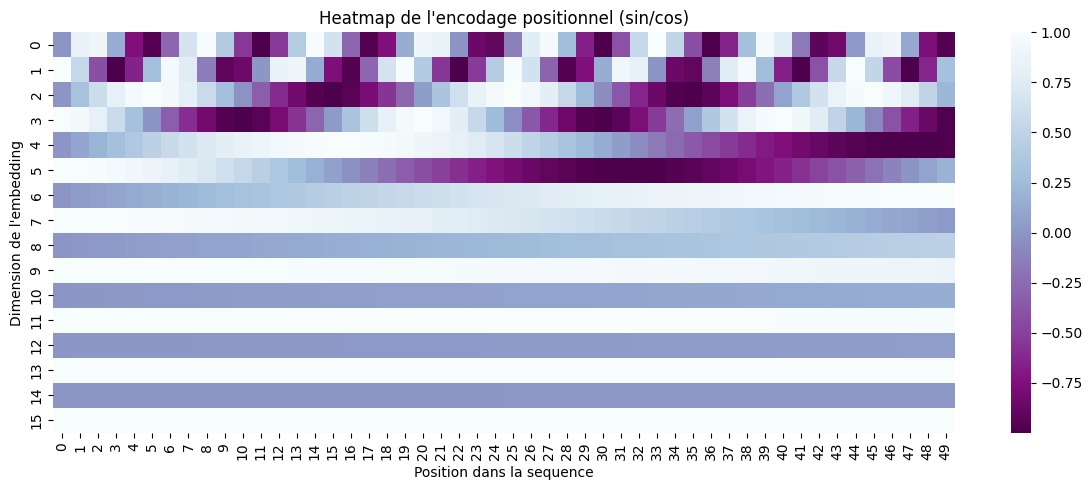

In [48]:
d_model = 16
max_len = 50
ps = PositionalEncoding(d_model=d_model, max_len=max_len, dropout=0.0)

pe_matrix = ps.pe[0].cpu().numpy()

plt.figure(figsize=(12, 5))
seaborn.heatmap(pe_matrix.T, cmap=plt.cm.BuPu_r, center=0)
plt.title("Heatmap de l'encodage positionnel (sin/cos)")
plt.xlabel("Position dans la sequence")
plt.ylabel("Dimension de l'embedding")
plt.tight_layout()
plt.show()


In [13]:
class TransformerEncoderModel(nn.Module):
    def __init__(self, vocab_size, d_model, N, h, d_ff, dropout):
        super().__init__()

        self.embed = Embeddings(vocab_size, d_model)
        self.pos = PositionalEncoding(d_model, dropout=dropout)

        attn = MultiHeadedAttention(h, d_model, dropout)
        ff = PositionwiseFeedForward(d_model, d_ff, dropout)

        block = TransformerEncoderBlock(d_model, attn, ff, dropout)
        self.encoder = Encoder(block, N)

    def forward(self, x, mask):
        x = self.embed(x)
        x = self.pos(x)
        return self.encoder(x, mask)


In [16]:
# Hyperparamètres simples pour le test
vocab_size = 100      # taille du vocabulaire
d_model = 32          # dimension des embeddings
N = 2                 # nombre de blocs encodeurs
h = 4                 # nombre de têtes
d_ff = 128             # dimension du feed-forward
dropout = 0.1

model = TransformerEncoderModel(
    vocab_size=vocab_size,
    d_model=d_model,
    N=N,
    h=h,
    d_ff=d_ff,
    dropout=dropout
)

batch_size = 10
seq_length = 5

# Tokens aléatoires (entiers entre 0 et vocab_size-1)
x = torch.randint(0, vocab_size, (batch_size, seq_length))
output = model(x, mask=None)

print("Entrée :", x.shape)
print("Sortie :", output.shape)

x

Entrée : torch.Size([10, 5])
Sortie : torch.Size([10, 5, 32])


tensor([[69, 97, 21, 50, 48],
        [38, 11, 45, 84, 16],
        [56, 25, 17, 52,  1],
        [16, 69, 91, 95, 90],
        [56, 40, 86, 53, 90],
        [80, 62, 37, 31, 72],
        [40, 51,  3, 99, 60],
        [94, 48, 96, 15, 79],
        [ 3, 22, 85,  8, 74],
        [ 5, 40,  5, 61, 89]])